In [2]:
import pandas as pd
import numpy as np
np.set_printoptions(threshold=10000, linewidth=10000)
import sklearn
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
'''write train data to csv, with output column'''

#start with zero array to populate with NMR data
array = np.zeros((0,2201))
for i in range(1000):
    temp_df = pd.read_csv("../RMN/train/Input/CPMG_"+f"{i:03d}.csv", sep="\t")
    #correct strings
    temp_df.T2_data = temp_df.T2_data.str.replace(",",".")
    temp_df.T2_data = temp_df.T2_data.str.replace(" ","").astype(float)#/1000
    #clip at zero
    # temp_df.T2_data = temp_df.T2_data.apply(lambda v: max(0,v))
    #add row with contents of current file
    array = np.vstack((array,temp_df.T2_data))

# scaler = sklearn.preprocessing.MinMaxScaler()
# array = scaler.fit_transform(array.T).T
train_df = pd.DataFrame(array)

#adding y column to df
train_df['y'] = pd.read_csv("../RMN/train/Output/OilSat.csv", sep="\t")['Oil_Sat']

#writing to csv file
# train_df.to_csv("./data_train.csv", sep="\t", index=False)
# train_df

'''write test data to csv'''

#start with zero array to populate with NMR data
array = np.zeros((0,2201))
for i in range(1000):
    temp_df = pd.read_csv("../RMN/test/Input/CPMG_"+f"{i:03d}.csv", sep="\t")
    #for test, no text correction, no clipping
    temp_df.T2_data = temp_df.T2_data.apply(lambda v: max(0,v))
    array = np.vstack((array,temp_df.T2_data))
# array = scaler.fit_transform(array.T).T
test_df = pd.DataFrame(array)
# test_df.to_csv("./data_test.csv", sep="\t", index=False)

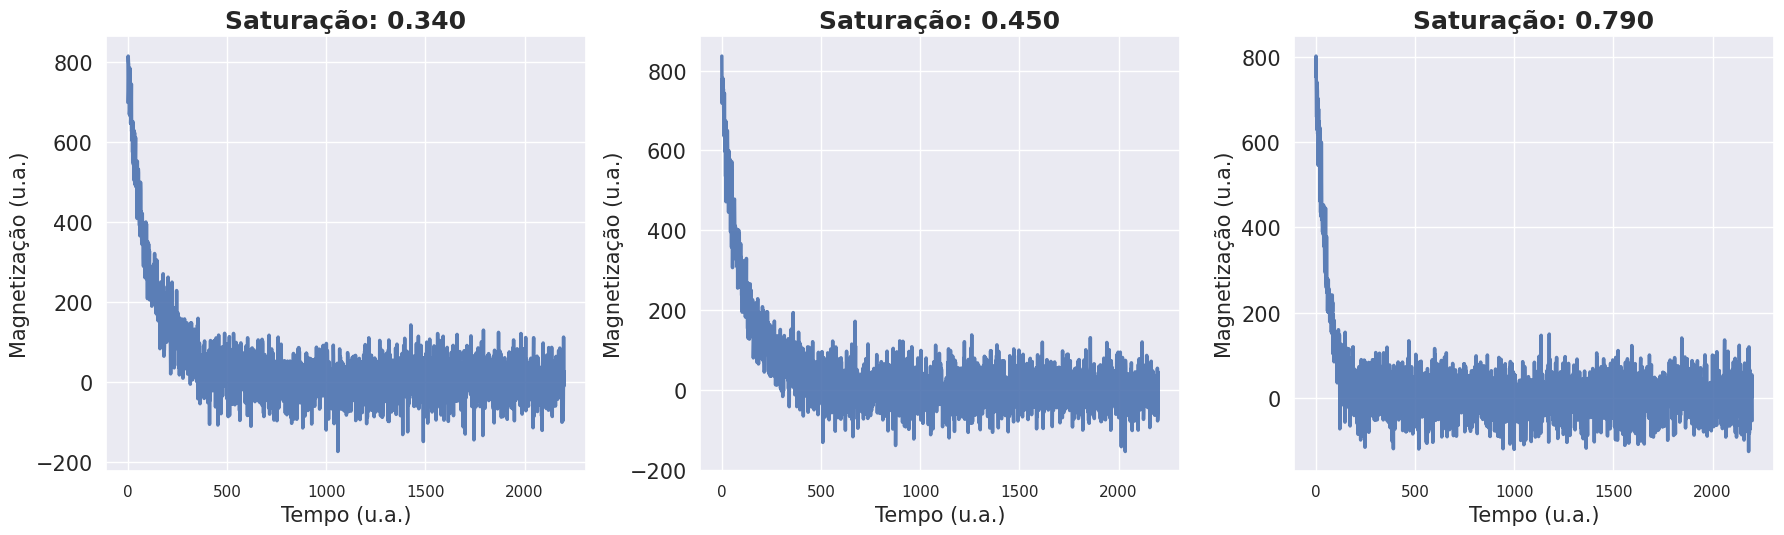

In [22]:
# Assumindo que 'train_df' já está carregado no seu ambiente.

# --- 1. Define um estilo visual mais agradável (opcional, mas recomendado) ---
# Isso muda a aparência de todos os plots seguintes (grid, fontes, cores).
sns.set_theme(style="darkgrid", palette="deep")

# --- 2. Criação da figura (subplots) ---
# Aumentei um pouco a altura (de 5 para 6) para caberem melhor os títulos
fig, ax = plt.subplots(1, 3, figsize=(18, 6))

# --- 3. Loop para plotar ---

# É mais seguro pegar índices aleatórios que *existem* no DataFrame
# do que usar np.random.randint(1,1000)
try:
    # replace=False garante que não pegaremos o mesmo índice 3x
    indices_aleatorios = np.random.choice(train_df.index, 3, replace=False)
except ValueError as e:
    print(f"Erro: {e}. Verifique se train_df tem pelo menos 3 linhas.")
    # Se der erro, usamos os índices padrão 0, 1, 2 como fallback
    indices_aleatorios = train_df.index[:3]


for i, j in enumerate(indices_aleatorios): # 'i' será 0, 1, 2. 'j' será o índice real (ex: 5, 450, 900)
    
    # Pega os dados da amostra (features) e o valor de 'y'
    amostra_features = train_df.loc[j].values[:-1]
    saturacao_oleo = train_df.loc[j, 'y'] # Pegando o valor de 'y'

    # --- Melhorias no plot ---
    ax[i].plot(amostra_features, 
               linewidth=2.5,  # Linha mais espessa
               alpha=0.9,      # Leve transparência
               # marker='o',       # Adiciona marcadores nos pontos
               markersize=4,
               linestyle='-')  # Linha sólida (pode mudar para '--' se preferir)

    # --- Títulos e Labels (Conforme solicitado) ---
    
    # Título do sub-plot, formatando o 'y' (float) com 4 casas decimais
    ax[i].set_title(f"Saturação: {saturacao_oleo:.3f}", fontsize=18,  fontweight='bold')
    
    # Labels dos eixos
    ax[i].set_xlabel("Tempo (u.a.)", fontsize=15)
    
    # O comentário original dizia "clip and normalization"
    ax[i].set_ylabel("Magnetização (u.a.)", fontsize=15)
    ax[i].tick_params(axis='y', labelsize=15)

# --- 4. Ajuste final e exibição ---

# Ajusta o layout para evitar que títulos e labels se sobreponham
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Ajusta o 'rect' para caber o suptitle
plt.show()

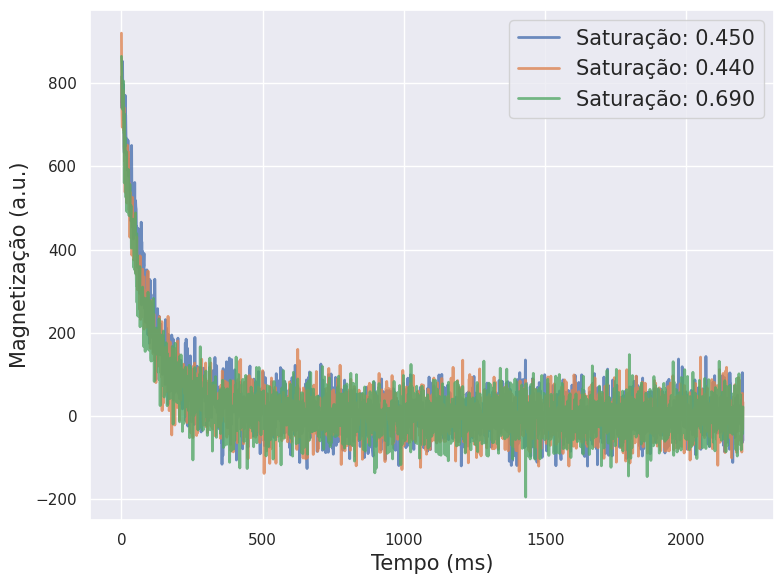

In [66]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
# Assumindo que 'train_df' já está carregado no seu ambiente.

# --- 1. Define o estilo ---
sns.set_theme(style="darkgrid", palette="deep")

# --- 2. Criação da figura (APENAS UM gráfico) ---
# Alterado de (1, 3) para (1, 1) e ajustado o tamanho (figsize)
fig, ax = plt.subplots(1, 1, figsize=(8, 6)) # Agora 'ax' é um único eixo

# --- 3. Seleção de índices ---
try:
    # replace=False garante que não pegaremos o mesmo índice 3x
    indices_aleatorios = np.random.choice(train_df.index, 3, replace=False)
except ValueError as e:
    print(f"Erro: {e}. Verifique se train_df tem pelo menos 3 linhas.")
    indices_aleatorios = train_df.index[:3]


# --- 4. Loop para plotar (tudo no mesmo 'ax') ---
# Não precisamos mais do 'i' (enumerate)
for j in indices_aleatorios: 
    
    # Pega os dados da amostra
    amostra_features = train_df.loc[j].values[:-1]
    saturacao_oleo = train_df.loc[j, 'y'] # Pegando o valor de 'y'

    # Plotamos tudo no mesmo 'ax'
    # Adicionamos o parâmetro 'label' para criar a legenda
    ax.plot(amostra_features, 
            linewidth=2.0,  # Linha um pouco mais fina, pois são 3
            alpha=0.8,      # Leve transparência
            # marker='o',       
            markersize=5,     # Marcador um pouco maior
            linestyle='-',
            # O label de cada linha mostrará o índice e a saturação
            label=f"Saturação: {saturacao_oleo:.3f}") 

# --- 5. Títulos, Labels e Legenda (FORA do loop) ---

# # Título geral para o gráfico
# ax.set_title(f"Comparação de 3 Amostras Aleatórias", 
#              fontsize=18, fontweight='bold')

# Labels dos eixos (só precisamos definir uma vez)
ax.set_xlabel("Tempo (ms)", fontsize=15)
ax.set_ylabel("Magnetização (a.u.)", fontsize=15)

# Adiciona a legenda para identificar qual linha é qual
# 'loc="best"' tenta posicionar a legenda no melhor lugar
ax.legend( fontsize=15, loc='best')

# --- 6. Ajuste final e exibição ---
plt.tight_layout() # Ajusta o layout
plt.show()

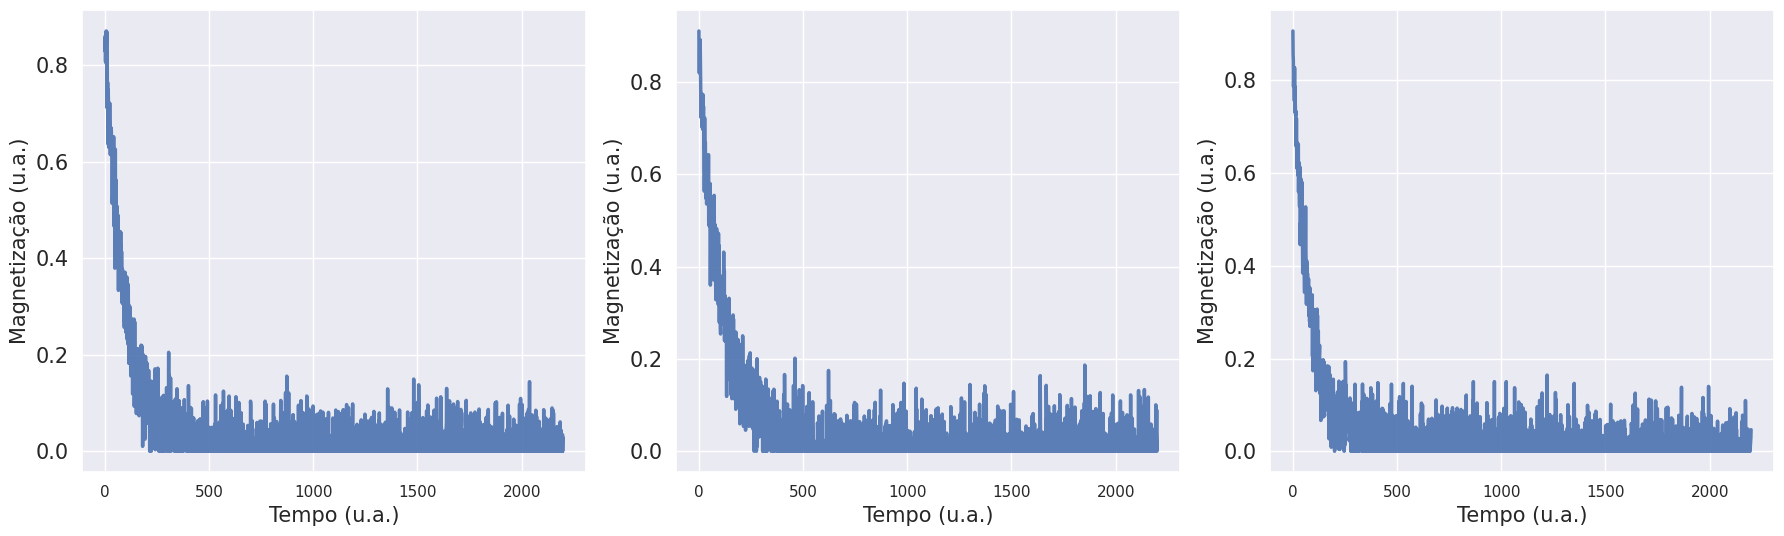

In [23]:
# Assumindo que 'test_df' já está carregado no seu ambiente.

# --- 1. Define um estilo visual mais agradável (opcional, mas recomendado) ---
# Isso muda a aparência de todos os plots seguintes (grid, fontes, cores).
sns.set_theme(style="darkgrid", palette="deep")

# --- 2. Criação da figura (subplots) ---
# Aumentei um pouco a altura (de 5 para 6) para caberem melhor os títulos
fig, ax = plt.subplots(1, 3, figsize=(18, 6))

# --- 3. Loop para plotar ---

# É mais seguro pegar índices aleatórios que *existem* no DataFrame
# do que usar np.random.randint(1,1000)
try:
    # replace=False garante que não pegaremos o mesmo índice 3x
    indices_aleatorios = np.random.choice(test_df.index, 3, replace=False)
except ValueError as e:
    print(f"Erro: {e}. Verifique se test_df tem pelo menos 3 linhas.")
    # Se der erro, usamos os índices padrão 0, 1, 2 como fallback
    indices_aleatorios = test_df.index[:3]


for i, j in enumerate(indices_aleatorios): # 'i' será 0, 1, 2. 'j' será o índice real (ex: 5, 450, 900)
    
    # Pega os dados da amostra (features) e o valor de 'y'
    amostra_features = test_df.loc[j].values[:-1]
    # saturacao_oleo = test_df.loc[j, 'y'] # Pegando o valor de 'y'

    # --- Melhorias no plot ---
    ax[i].plot(amostra_features, 
               linewidth=2.5,  # Linha mais espessa
               alpha=0.9,      # Leve transparência
               # marker='o',       # Adiciona marcadores nos pontos
               markersize=4,
               linestyle='-')  # Linha sólida (pode mudar para '--' se preferir)

    # --- Títulos e Labels (Conforme solicitado) ---
    
    # Título do sub-plot, formatando o 'y' (float) com 4 casas decimais
    # ax[i].set_title(f"Saturação: {saturacao_oleo:.3f}", fontsize=18,  fontweight='bold')
    
    # Labels dos eixos
    ax[i].set_xlabel("Tempo (u.a.)", fontsize=15)
    
    # O comentário original dizia "clip and normalization"
    ax[i].set_ylabel("Magnetização (u.a.)", fontsize=15)
    ax[i].tick_params(axis='y', labelsize=15)
    

# --- 4. Ajuste final e exibição ---

# Ajusta o layout para evitar que títulos e labels se sobreponham
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Ajusta o 'rect' para caber o suptitle
plt.show()

/tmp/ipykernel_423345/809325875.py:51: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend( fontsize=15, loc='best')


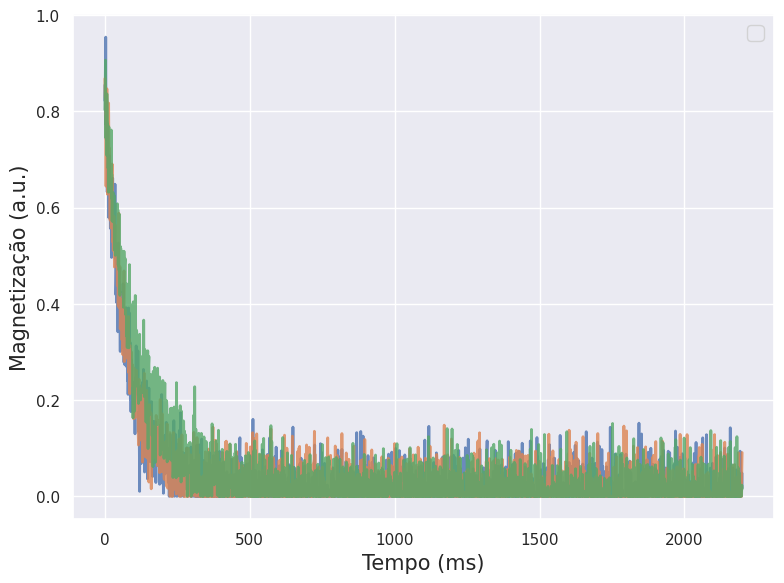

In [68]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
# Assumindo que 'test_df' já está carregado no seu ambiente.

# --- 1. Define o estilo ---
sns.set_theme(style="darkgrid", palette="deep")

# --- 2. Criação da figura (APENAS UM gráfico) ---
# Alterado de (1, 3) para (1, 1) e ajustado o tamanho (figsize)
fig, ax = plt.subplots(1, 1, figsize=(8, 6)) # Agora 'ax' é um único eixo

# --- 3. Seleção de índices ---
try:
    # replace=False garante que não pegaremos o mesmo índice 3x
    indices_aleatorios = np.random.choice(test_df.index, 3, replace=False)
except ValueError as e:
    print(f"Erro: {e}. Verifique se test_df tem pelo menos 3 linhas.")
    indices_aleatorios = test_df.index[:3]


# --- 4. Loop para plotar (tudo no mesmo 'ax') ---
# Não precisamos mais do 'i' (enumerate)
for j in indices_aleatorios: 
    
    # Pega os dados da amostra
    amostra_features = test_df.loc[j].values[:-1]
    # saturacao_oleo = test_df.loc[j, 'y'] # Pegando o valor de 'y'

    # Plotamos tudo no mesmo 'ax'
    # Adicionamos o parâmetro 'label' para criar a legenda
    ax.plot(amostra_features, 
            linewidth=2.0,  # Linha um pouco mais fina, pois são 3
            alpha=0.8,      # Leve transparência
            # marker='o',       
            markersize=5,     # Marcador um pouco maior
            linestyle='-',) 

# --- 5. Títulos, Labels e Legenda (FORA do loop) ---

# # Título geral para o gráfico
# ax.set_title(f"Comparação de 3 Amostras Aleatórias", 
#              fontsize=18, fontweight='bold')

# Labels dos eixos (só precisamos definir uma vez)
ax.set_xlabel("Tempo (ms)", fontsize=15)
ax.set_ylabel("Magnetização (a.u.)", fontsize=15)

# Adiciona a legenda para identificar qual linha é qual
# 'loc="best"' tenta posicionar a legenda no melhor lugar
ax.legend( fontsize=15, loc='best')

# --- 6. Ajuste final e exibição ---
plt.tight_layout() # Ajusta o layout
plt.show()

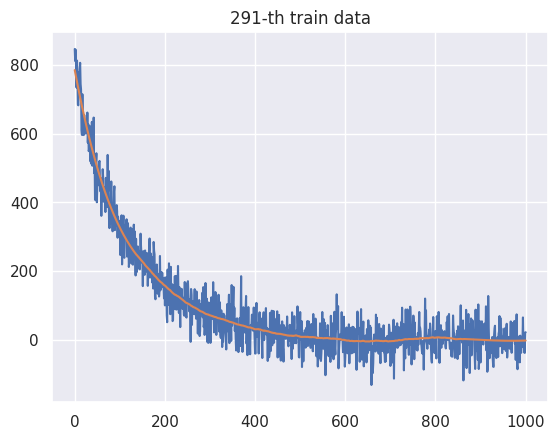

In [69]:
import scipy as sp
from scipy.signal import savgol_filter

j = np.random.randint(1,1000,1)[0]
# signal = train_df.drop('y',axis=1).loc[j,:1000]
signal = train_df.loc[j,:1000]
plt.plot(signal)
window_length, polyorder = 271, 3
plt.plot(savgol_filter(signal, window_length, polyorder))
plt.title(str(j)+"-th train data");

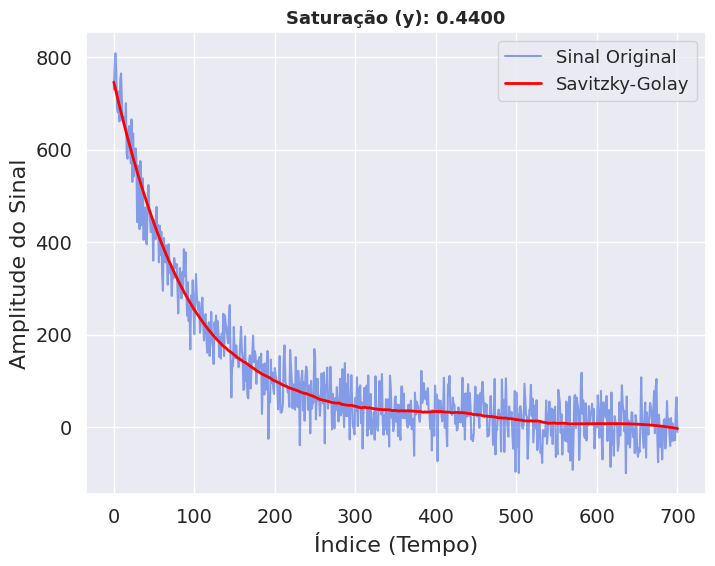

In [70]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.signal import savgol_filter

# Estilo simples
sns.set_theme(style="darkgrid")

# Sua lógica de seleção
j = np.random.randint(0, len(train_df))
signal = train_df.loc[j, :700] # Pega as primeiras 1000 colunas como sinal
y_valor = train_df.loc[j, 'y']  # Pega o valor alvo para o título

# Parâmetros do filtro
window_length, polyorder = 271, 3
signal_smooth = savgol_filter(signal, window_length, polyorder)

# Plot direto
plt.figure(figsize=(8, 6))

# Original (Cinza e transparente para fundo)
plt.plot(signal, color='royalblue', alpha=0.6, label='Sinal Original')

# Filtrado (Cor sólida e mais grosso)
plt.plot(signal_smooth, color='red', linewidth=2, label='Savitzky-Golay')
plt.xlabel("Índice (Tempo)", fontsize=16)
plt.ylabel("Amplitude do Sinal", fontsize=16)

# Aumentando fonte dos números nos eixos e da legenda
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
# Título com o valor de Y
plt.title(f"Saturação (y): {y_valor:.4f}", fontsize=13, fontweight='bold')
plt.legend(fontsize=13)
plt.show()

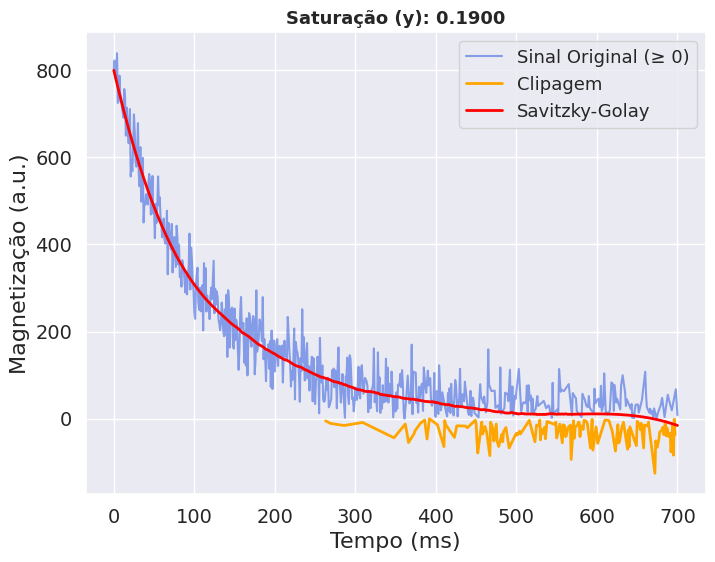

In [71]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.signal import savgol_filter

# Estilo simples
sns.set_theme(style="darkgrid")

# Sua lógica de seleção
j = np.random.randint(0, len(train_df))
signal = train_df.loc[j, :700]  # Pega as primeiras 700 colunas como sinal
y_valor = train_df.loc[j, 'y']

# Parâmetros do filtro
window_length, polyorder = 271, 3
signal_smooth = savgol_filter(signal, window_length, polyorder)

# Máscaras para valores negativos
mask_neg = signal < 0
mask_pos = signal >= 0

# Plot
plt.figure(figsize=(8, 6))

# Sinal original separado: positivo (azul) e negativo (amarelo)
plt.plot(np.where(mask_pos)[0], signal[mask_pos], color='royalblue', alpha=0.6, label='Sinal Original (≥ 0)')
plt.plot(np.where(mask_neg)[0], signal[mask_neg], color='orange', linewidth=2, label='Clipagem')

# Filtrado completo (mantém vermelho normal)
plt.plot(signal_smooth, color='red', linewidth=2, label='Savitzky-Golay')

plt.xlabel("Tempo (ms)", fontsize=16)
plt.ylabel("Magnetização (a.u.)", fontsize=16)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.title(f"Saturação (y): {y_valor:.4f}", fontsize=13, fontweight='bold')
plt.legend(fontsize=13)
plt.show()


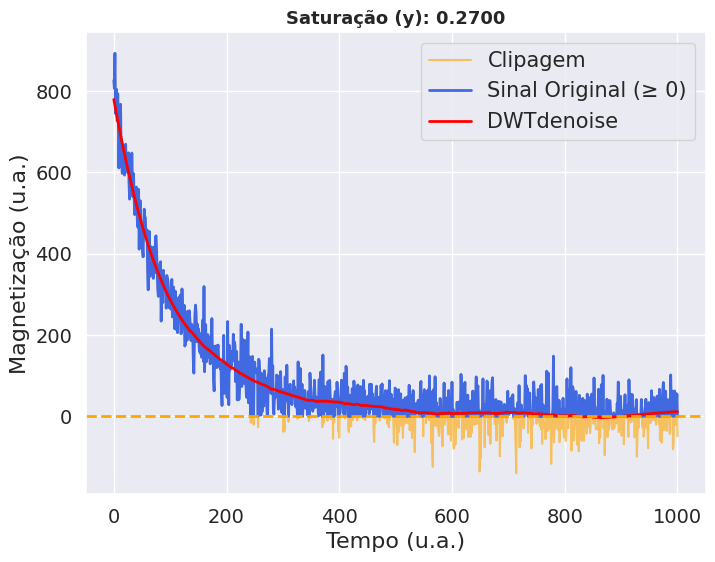

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.signal import savgol_filter

# Estilo simples
sns.set_theme(style="darkgrid")

# Seleção do sinal
j = np.random.randint(0, len(train_df))
signal = train_df.loc[j, :1000]
y_valor = train_df.loc[j, 'y']

# Filtro Savitzky-Golay
window_length, polyorder = 271, 3
signal_smooth = savgol_filter(signal, window_length, polyorder)

# --- Abordagem ReLU ---
signal_relu = np.maximum(signal, 0)        # Mantém apenas valores ≥0

# Plot
plt.figure(figsize=(8, 6))

# Sinal (≥ 0) em azul

# Sinal (< 0) em amarelo

# Sinal filtrado (vermelho)
plt.plot(signal, color='orange', alpha=0.6, label='Clipagem')
plt.plot(signal_relu, color='royalblue', linewidth=2, label='Sinal Original (≥ 0)')
plt.plot(signal_smooth, color='red', linewidth=2, label='DWTdenoise')
plt.axhline(0, color='orange', linewidth=2, linestyle='--')


plt.xlabel("Tempo (u.a.)", fontsize=16)
plt.ylabel("Magnetização (u.a.)", fontsize=16)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.title(f"Saturação (y): {y_valor:.4f}", fontsize=13, fontweight='bold')
plt.legend(fontsize=15)
plt.show()


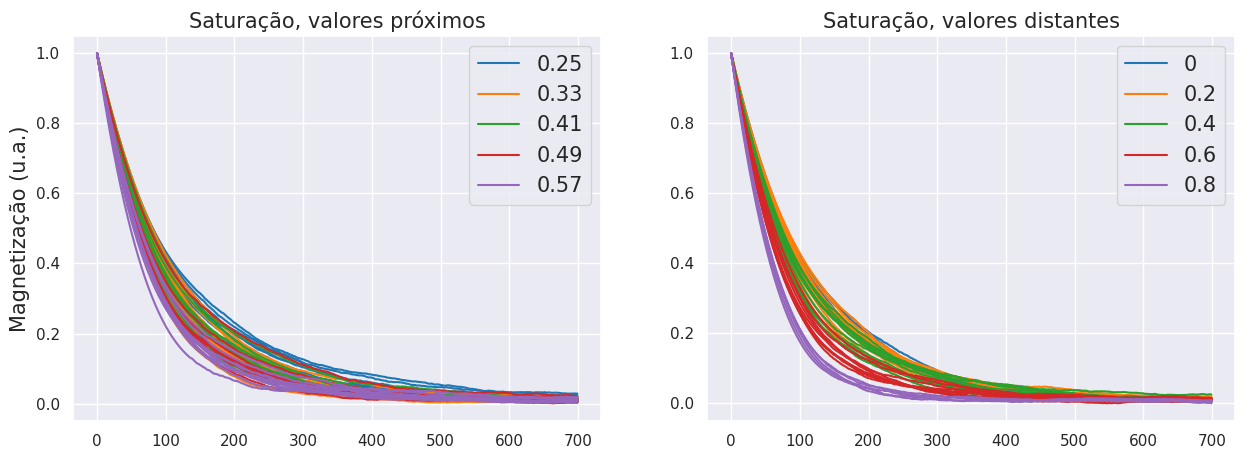

In [43]:
sns.set_theme(style="darkgrid", palette="deep")

train_df = pd.read_csv('data_train_post_n_savgol.csv', sep="\t")
cmap = plt.cm.tab10
fig, ax = plt.subplots(1,2,figsize=(15,5))

for i,sat_oil in enumerate([.25,.33,.41,.49,.57]):
    sel_train_df = train_df[train_df['y']==sat_oil]
    ax[0].plot(range(700),sel_train_df.iloc[0,:700], c=cmap(i%10), label=f'{str(sat_oil)}')
    for j in range(1,len(sel_train_df)):
        ax[0].plot(range(700),sel_train_df.iloc[j,:700], c=cmap(i%10))
ax[0].legend(fontsize=15)
ax[0].set_title('Saturação, valores próximos', fontsize=15)
# ax[0].set_xlabel("Tempo (u.a.)", fontsize=15)
ax[0].set_ylabel("Magnetização (u.a.)", fontsize=15)

for i,sat_oil in enumerate([0,.2,.4,.6,.8]):
    sel_train_df = train_df[train_df['y']==sat_oil]
    ax[1].plot(range(700),sel_train_df.iloc[0,:-1], c=cmap(i%10), label=f'{str(sat_oil)}')
    for j in range(1,len(sel_train_df)):
        ax[1].plot(range(700),sel_train_df.iloc[j,:-1], c=cmap(i%10))
ax[1].legend(fontsize=15)
ax[1].set_title('Saturação, valores distantes', fontsize=15)
# ax[1].set_xlabel("Tempo (u.a.)", fontsize=15)
    
plt.show();

In [49]:
train_DWT_df = pd.read_csv('data_train_post_n_smoothing.csv', sep='\t')
pca = sklearn.decomposition.PCA(n_components=.999)
pca.fit(train_DWT_df.iloc[:,:-1])

,n_components,0.999
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,None


In [50]:
pca.transform(train_DWT_df.iloc[:,:-1]).shape

(1000, 11)

In [51]:
test_DWT_df = pd.read_csv('data_test_post_n_smoothing.csv', sep='\t')
pca2 = sklearn.decomposition.PCA(n_components=.999)
pca2.fit(test_DWT_df)

,n_components,0.999
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,None


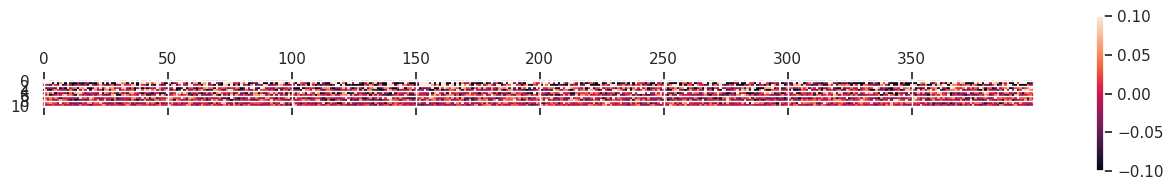

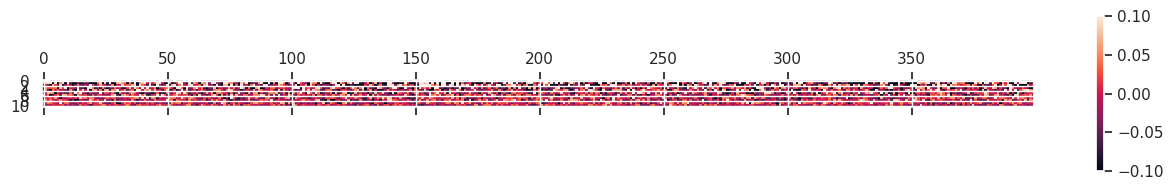

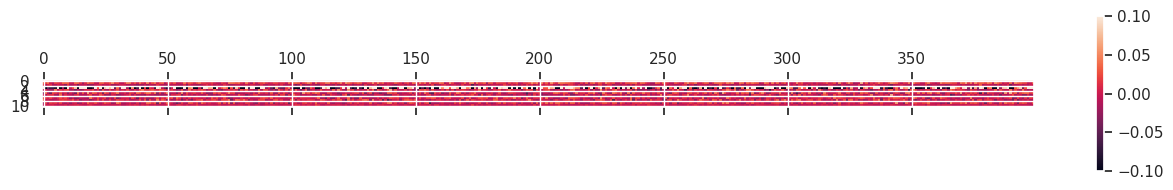

In [61]:
plt.matshow(pca.transform(train_DWT_df.iloc[:400,:-1]).T, vmin=-.1, vmax=.1)
plt.colorbar()
plt.matshow(pca2.transform(train_DWT_df.iloc[:400,:-1]).T, vmin=-.1, vmax=.1)
plt.colorbar()
plt.matshow(pca.transform(train_DWT_df.iloc[:400,:-1]).T - pca2.transform(train_DWT_df.iloc[:400,:-1]).T, vmin=-.1, vmax=.1)
plt.colorbar()

In [65]:
np.std(pca.transform(train_DWT_df.iloc[:400,:-1])), \
np.std(pca2.transform(train_DWT_df.iloc[:400,:-1])), \
np.std(pca.transform(train_DWT_df.iloc[:400,:-1]) - pca2.transform(train_DWT_df.iloc[:400,:-1]))

(np.float64(0.30765968735331706),
 np.float64(0.30776205527930434),
 np.float64(0.049338344035497306))